<h1 style="text-align:center;">IC-152 Final Consolidated Marks Analysis </h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [38]:
df = pd.read_csv('data/IC152_Finalmarks.csv')
df = df.rename({'IIT Mandi Roll No.': "roll", "Programme": "branch", "Total(100)": "total"}, axis=1).set_index('roll')
df

,Name,branch,total,Round
roll,,,,
B25331,REMAN DEY,Bachelor of Technology in Engineering Physics,87.10,88
B25132,DAKSH,Bachelor of Technology in Computer Science an,83.30,84
B25126,ARYAN SISODIYA,Bachelor of Technology in Computer Science an,81.95,82
B25138,GRISHMA GUPTA,Bachelor of Technology in Computer Science an,81.10,82
B25136,GATIK GUPTA,Bachelor of Technology in Computer Science an,79.20,80
...,...,...,...,...
B25445,AZMEERA RAVI KIRAN,Bachelor of Technology in Mechanical Engineer,18.50,19
B25507,N DURGA PRASAD,Bachelor of Technology in Microelectronics & V,17.25,18
B25086,MANDELA RAM SAISRI PRAKAS,Bachelor of Technology in Civil Engineering,0.00,0


In [66]:
df

,Name,branch,total,Round
roll,,,,
B25331,REMAN DEY,EP,87.10,88
B25132,DAKSH,CSE,83.30,84
B25126,ARYAN SISODIYA,CSE,81.95,82
B25138,GRISHMA GUPTA,CSE,81.10,82
B25136,GATIK GUPTA,CSE,79.20,80
...,...,...,...,...
B25445,AZMEERA RAVI KIRAN,ME,18.50,19
B25507,N DURGA PRASAD,VLSI,17.25,18
B25086,MANDELA RAM SAISRI PRAKAS,CE,0.00,0


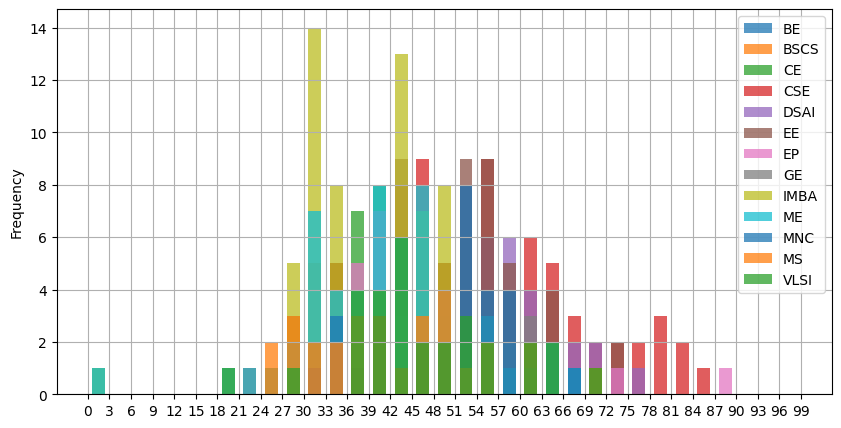

In [215]:
plt.figure(figsize=(10,5))
df.groupby('branch')['Round'].plot(kind='hist', rwidth=0.6, bins=bins, alpha=0.75)
plt.legend()
plt.xticks(bins)
plt.grid()

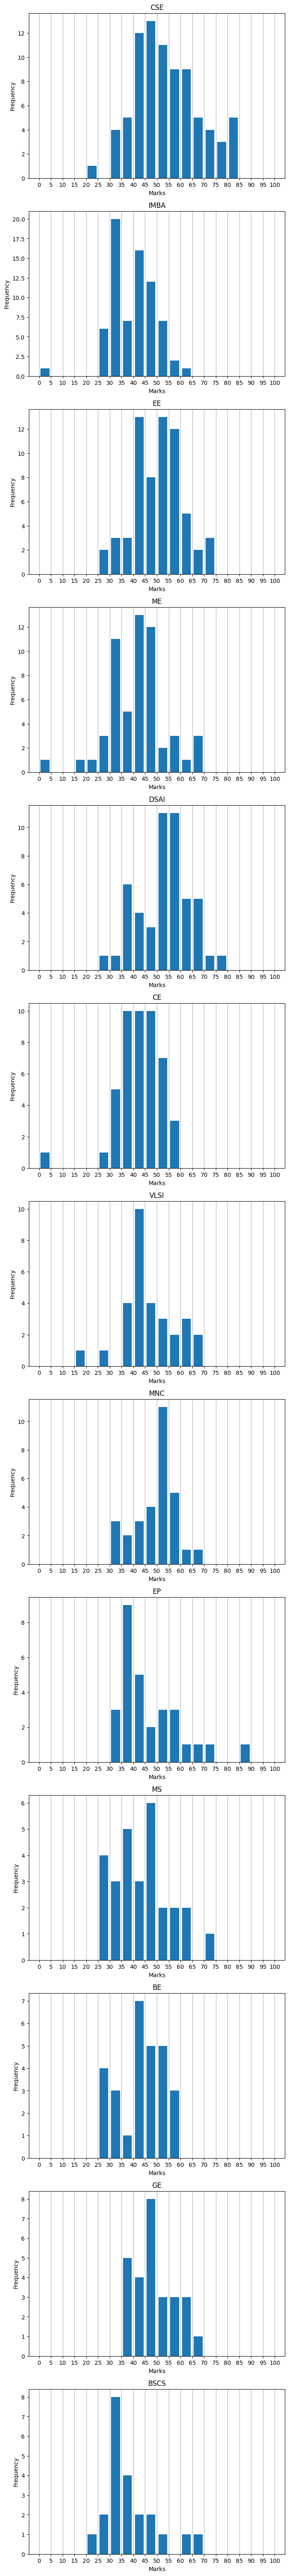

In [146]:
plt.figure(figsize=(8, 80))
for i in range(df['branch'].value_counts().shape[0]):
    plt.subplot(df['branch'].value_counts().shape[0],1, i+1)
    bins = np.arange(0,105,5)
    df[df['branch'] == df['branch'].value_counts().index[i]]['Round'].plot(kind='hist', bins=bins, rwidth=0.75)
    plt.xticks(bins)
    plt.grid(axis='x')
    plt.title(df['branch'].value_counts().index[i])
    plt.xlabel("Marks")
    plt.ylabel("Frequency")

plt.show()

46.174067495559505
12.089887349792287


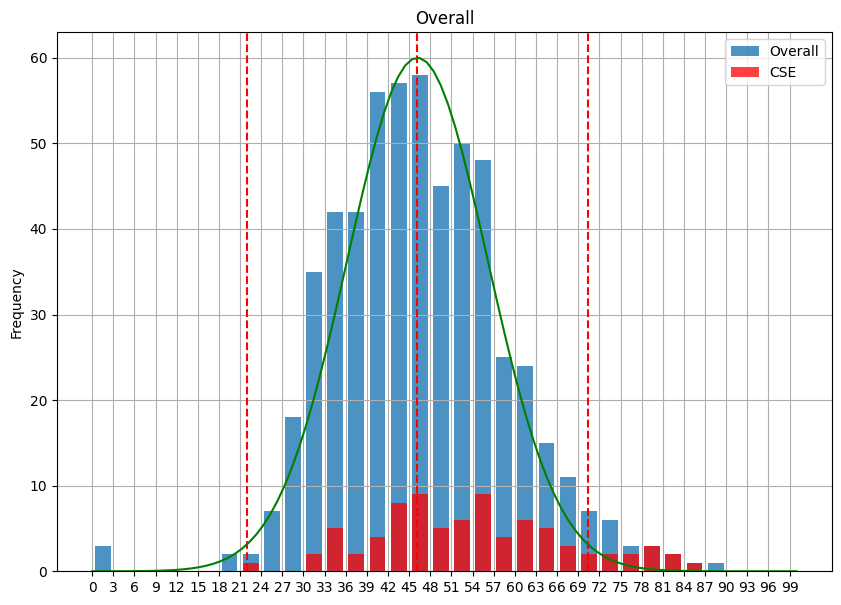

In [170]:
bins = np.arange(0, 100, 3)

plt.figure(figsize=(10,7))

df['Round'].plot(kind='hist', bins=bins, rwidth=0.75, alpha=0.8, label="Overall")
plt.xticks(bins, rotation=90)
plt.title("Overall")
plt.xlabel("Marks")
plt.ylabel("Frequency")

plt.axvline(df['Round'].mean(), color='red', linewidth=1.5, linestyle="--")
plt.axvline(df['Round'].mean() + 2*df['Round'].std(), color='red', linewidth=1.5, linestyle="--")
plt.axvline(df['Round'].mean() - 2*df['Round'].std(), color='red', linewidth=1.5, linestyle="--")

print(df['Round'].mean())
print(df['Round'].std())

mu = df['Round'].mean()
sigma = df['Round'].std()+2

df[df['branch'] == 'CSE']['Round'].plot(kind='hist', bins=bins, rwidth=0.75, alpha=0.75, color='red', label="CSE")

domain = np.linspace(0, 100, 100)
guassian = 60*np.exp(-((domain-mu)/sigma)**2)

plt.plot(domain, guassian, color='green')
plt.grid()

plt.legend()

In [139]:
df['rank'] = df['total'].rank(ascending=False)
df = df.reset_index().set_index('rank')

df

,roll,Name,branch,total,Round
rank,,,,,
1.0,B25331,REMAN DEY,EP,87.10,88
2.0,B25132,DAKSH,CSE,83.30,84
3.0,B25126,ARYAN SISODIYA,CSE,81.95,82
4.0,B25138,GRISHMA GUPTA,CSE,81.10,82
5.5,B25136,GATIK GUPTA,CSE,79.20,80
...,...,...,...,...,...
559.0,B25445,AZMEERA RAVI KIRAN,ME,18.50,19
560.0,B25507,N DURGA PRASAD,VLSI,17.25,18
562.0,B25086,MANDELA RAM SAISRI PRAKAS,CE,0.00,0


In [194]:
newdf = pd.DataFrame(df['branch'].unique(), columns=['branch'])
newdf

,branch
0,EP
1,CSE
2,DSAI
3,EE
4,MS
5,VLSI
6,MNC
7,BSCS
8,ME
9,GE


In [189]:
((df.groupby('branch')['Round'].sum()/df['branch'].value_counts().sort_index()).sort_values(ascending=False)).reset_index()

,branch,0
0,CSE,53.567901
1,DSAI,52.510204
2,EE,50.062500
3,MNC,49.166667
4,GE,48.222222
5,EP,46.551724
6,VLSI,46.433333
7,MS,43.000000
8,BE,42.964286
9,CE,42.127660


In [ ]:
newdf = newdf.merge(((df.groupby('branch')['Round'].sum()/df['branch'].value_counts(
).sort_index()).sort_values(ascending=False)).reset_index(), on='branch')

In [180]:
df['branch'].value_counts().sort_index()

branch
BE      28
BSCS    22
CE      47
CSE     81
DSAI    49
EE      64
EP      29
GE      27
IMBA    72
ME      56
MNC     30
MS      28
VLSI    30
Name: count, dtype: int64

In [199]:
newdf = newdf.rename({0: "branch average"}, axis=1)
newdf

,branch,branch average
0,EP,46.551724
1,CSE,53.567901
2,DSAI,52.510204
3,EE,50.062500
4,MS,43.000000
5,VLSI,46.433333
6,MNC,49.166667
7,BSCS,37.636364
8,ME,41.000000
9,GE,48.222222


Text(0.5, 1.0, 'Branch wise average marks')

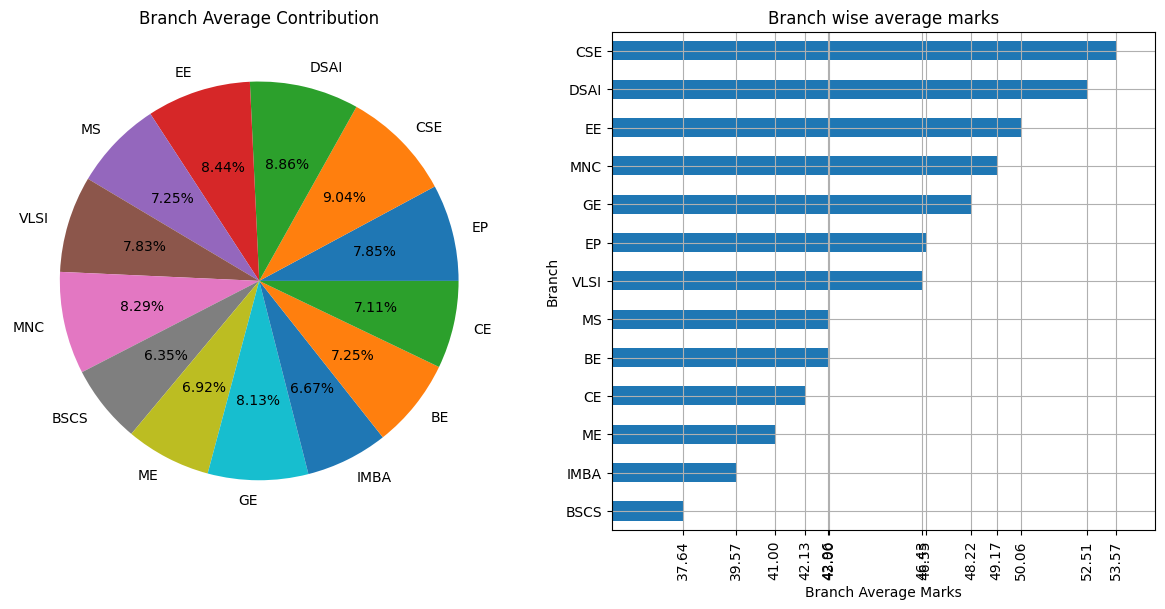

In [239]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
newdf['branch average'].plot(kind='pie', autopct="%1.2f%%")
plt.title("Branch Average Contribution")
plt.ylabel("")

plt.subplot(1,2,2)
newdf['branch average'].sort_values().plot(kind='barh')
plt.ylabel("Branch")
plt.xlabel("Branch Average Marks")

plt.xticks(newdf['branch average'], rotation=90)

plt.tight_layout()
plt.grid()
plt.xlim(35,55)

plt.title("Branch wise average marks")